In [1]:
import MetaTrader5 as mt5
from datetime import datetime
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
import optuna
import numpy as np
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym
from gymnasium import spaces
import gc
from wandb.integration.sb3 import WandbCallback
import wandb
from alibi_detect.od import IForest
from stable_baselines3.common.callbacks import BaseCallback
import torch
import os
from stable_baselines3.common.callbacks import EvalCallback
import matplotlib.pyplot as plt
import random
import time

d:\dev\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
d:\dev\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` 

## Config

In [2]:
MT5_LOGIN = int(os.environ.get('MT5_LOGIN'))
MT5_PASSWORD = os.environ.get('MT5_PASSWORD')
MT5_SERVER = os.environ.get('MT5_SERVER')
SYMBOL = "EURUSD"
TIMEFRAME = mt5.TIMEFRAME_D1
START = datetime(2020,1,1)
END = datetime(2025,1,1)
MODEL_PATH = "models/best_ppo_forex.zip"
RESUME_TIMESTEPS = 100_000

## Connexion MT5 et récupération historique

In [3]:
# --- Paramètres MT5 ---
SYMBOL = "EURUSD"
TIMEFRAME = mt5.TIMEFRAME_M15
START = pd.Timestamp("2024-01-01")
END = pd.Timestamp("2025-10-01")
PARQUET_PATH = f"data/{SYMBOL.lower()}_{TIMEFRAME}.parquet"


# --- Fonction de connexion ---
def connect_mt5(max_retries=3, wait_time=2):
    """Connexion robuste à MetaTrader 5"""
    print("🔹 Fermeture d'éventuelles connexions précédentes...")
    mt5.shutdown()
    time.sleep(1)

    for attempt in range(1, max_retries + 1):
        print(f"\n🔄 Tentative {attempt}/{max_retries} d'initialisation de MetaTrader 5...")
        if not mt5.initialize():
            err = mt5.last_error()
            print(f"❌ Échec de l'initialisation : {err}")
            time.sleep(wait_time)
            continue

        mt5_version = mt5.version()
        print(f"✅ MetaTrader 5 initialisé : version {mt5_version}")

        if MT5_LOGIN:
            if not mt5.login(login=MT5_LOGIN, password=MT5_PASSWORD, server=MT5_SERVER):
                err = mt5.last_error()
                print(f"❌ Connexion échouée : {err}")
                mt5.shutdown()
                time.sleep(wait_time)
                continue
            print("✅ Connexion réussie à MetaTrader 5.")
        return True

    return False


# --- Chargement ou téléchargement des données ---
if os.path.exists(PARQUET_PATH):
    print(f"📁 Chargement des données existantes depuis {PARQUET_PATH}")
    df_mt5 = pd.read_parquet(PARQUET_PATH)

else:
    print("🌐 Téléchargement des données depuis MetaTrader 5...")
    if connect_mt5():
        rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, START.to_pydatetime(), END.to_pydatetime())
        if rates is None:
            raise Exception("❌ Aucune donnée reçue depuis MT5.")
        
        df_mt5 = pd.DataFrame(rates)
        if df_mt5.empty:
            raise Exception("❌ Données vides — vérifie la période et le symbole.")

        # Mise en forme
        df_mt5["time"] = pd.to_datetime(df_mt5["time"], unit="s")
        df_mt5.columns = df_mt5.columns.str.lower()  # ✅ Colonnes en minuscules
        df_mt5.reset_index(drop=True, inplace=True)

        print(f"✅ {len(df_mt5)} barres téléchargées.")
        os.makedirs(os.path.dirname(PARQUET_PATH), exist_ok=True)
        df_mt5.to_parquet(PARQUET_PATH, index=False)
        print(f"💾 Données sauvegardées dans {PARQUET_PATH}")
        mt5.shutdown()
    else:
        raise Exception("❌ Impossible de se connecter à MT5.")


# --- Aperçu ---
print(df_mt5.head())

📁 Chargement des données existantes depuis data/eurusd_15.parquet
                 time     open     high      low    close  tick_volume  \
0 2024-01-02 00:00:00  1.10437  1.10451  1.10415  1.10449           93   
1 2024-01-02 00:15:00  1.10420  1.10450  1.10420  1.10426           77   
2 2024-01-02 00:30:00  1.10437  1.10437  1.10415  1.10428           69   
3 2024-01-02 00:45:00  1.10423  1.10441  1.10411  1.10439          136   
4 2024-01-02 01:00:00  1.10441  1.10447  1.10380  1.10382          508   

   spread  real_volume  
0      11            0  
1      13            0  
2      12            0  
3      11            0  
4       3            0  


In [4]:
df_mt5.head()

,time,open,high,low,close,tick_volume,spread,real_volume
0,2024-01-02 00:00:00,1.10437,1.10451,1.10415,1.10449,93,11,0
1,2024-01-02 00:15:00,1.10420,1.10450,1.10420,1.10426,77,13,0
2,2024-01-02 00:30:00,1.10437,1.10437,1.10415,1.10428,69,12,0
3,2024-01-02 00:45:00,1.10423,1.10441,1.10411,1.10439,136,11,0
4,2024-01-02 01:00:00,1.10441,1.10447,1.10380,1.10382,508,3,0


## Créer env compatible déjà utilisé dans notebook

In [ ]:
import gym
from gym import spaces
import numpy as np
import random

class ForexEnv(gym.Env):
    """
    Environnement Forex amélioré pour RL.
    - Reward basé sur PnL relatif
    - Observation enrichie : delta historique + position
    - Position : 0 = neutre, 1 = long, -1 = short
    """
    def __init__(self, df, transaction_cost=0.001, max_leverage=1.0, reward_window=10, hist_window=10):
        super().__init__()
        self.df = df.reset_index(drop=True)
        if 'close' not in self.df.columns:
            raise KeyError("La colonne 'close' est requise dans le DataFrame")

        # Paramètres
        self.transaction_cost = transaction_cost
        self.max_leverage = max_leverage
        self.reward_window = reward_window
        self.hist_window = hist_window

        # État interne
        self.current_step = 0
        self.balance = 10000.0
        self.initial_balance = self.balance
        self.max_balance = self.balance
        self.position = 0  # 0 neutre, 1 long, -1 short
        self.entry_price = 0.0
        self.pnl_history = []

        # Espaces
        self.action_space = spaces.Discrete(3)  # 0=neutre, 1=long, 2=short
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.hist_window + 1,),  # historique + position
            dtype=np.float32
        )

    def reset(self, **kwargs):
        self.current_step = 0
        self.balance = self.initial_balance
        self.max_balance = self.balance
        self.position = 0
        self.entry_price = 0.0
        self.pnl_history.clear()

        return self._next_obs(), {}

    def _next_obs(self):
        start = max(0, self.current_step - self.hist_window + 1)
        closes = self.df['close'].iloc[start:self.current_step + 1].values
        if len(closes) < self.hist_window:
            closes = np.pad(closes, (self.hist_window - len(closes), 0), mode='edge')

        deltas = np.diff(closes) / closes[:-1]
        obs = np.concatenate([deltas, [self.position]])
        return obs.astype(np.float32)

    def step(self, action):
        prev_price = float(self.df.loc[self.current_step, "close"])
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1
        truncated = False
        price = float(self.df.loc[self.current_step, "close"])
        delta = price - prev_price
        rel_return = delta / prev_price

        # --- Calcul du PnL ---
        pnl = self.position * rel_return * self.balance * self.max_leverage

        # --- Coût de transaction si changement de position ---
        cost = 0.0
        if (self.position == 1 and action == 2) or (self.position == -1 and action == 1):
            cost = self.transaction_cost * self.balance

        # --- Mise à jour de la position ---
        if action == 1:
            self.position = 1
        elif action == 2:
            self.position = -1
        # sinon conserve position

        # --- Mise à jour du solde ---
        self.balance += pnl - cost
        self.balance = max(self.balance, 0)
        self.max_balance = max(self.max_balance, self.balance)
        drawdown = (self.max_balance - self.balance) / max(self.max_balance, 1)

        # --- Historique pour reward ---
        normalized_pnl = pnl / self.initial_balance
        self.pnl_history.append(normalized_pnl)
        if len(self.pnl_history) > self.reward_window:
            self.pnl_history.pop(0)

        # --- Reward : mean/std du PnL local ---
        mean_pnl = np.mean(self.pnl_history)
        std_pnl = np.std(self.pnl_history) + 1e-8
        sharpe_local = mean_pnl / std_pnl if std_pnl > 0 else 0.0
        reward = sharpe_local - drawdown  # drawdown pénalise un peu

        obs = self._next_obs()
        info = {
            "balance": self.balance,
            "position": self.position,
            "pnl": pnl,
            "drawdown": drawdown,
        }

        # Stop si drawdown trop fort ou balance trop basse
        if drawdown > 0.3 or self.balance <= 100:
            done = True

        return obs, reward, done, truncated, info

In [ ]:
class RandomStartWrapper(gym.Wrapper):
    """
    Wrapper pour démarrer chaque épisode à un pas aléatoire dans l'historique.
    Compatible avec ForexEnv utilisant un historique de prix.
    """
    def __init__(self, env, min_offset=1, max_offset=None):
        super().__init__(env)
        self.min_offset = min_offset
        self.max_offset = max_offset

    def reset(self, **kwargs):
        # Reset de l'environnement de base
        obs, info = self.env.reset(**kwargs)

        # Calcul du pas maximum possible
        total_steps = len(self.env.unwrapped.df)
        max_off = self.max_offset if self.max_offset is not None else max(1, total_steps // 10)

        # Décalage aléatoire
        offset = random.randint(self.min_offset, min(max_off, total_steps - self.env.reward_window - 1))
        self.env.unwrapped.current_step = offset

        # Observation à partir de cette position
        obs = self.env.unwrapped._next_obs()

        return obs, info

In [ ]:
class EquityVisualizerCallback(BaseCallback):
    """
    Callback pour tracer l'évolution du capital (équity) et les positions.
    Compatible avec DummyVecEnv et ForexEnv.
    """
    def __init__(self, env, verbose=0):
        super().__init__(verbose)
        self.env = env
        self.equity = []
        self.positions = []
        self.prices = []
        self.episode_starts = []

    def _on_step(self) -> bool:
        # Récupérer l'état depuis l'env
        balances = self.training_env.get_attr("balance")
        positions = self.training_env.get_attr("position")
        dfs = self.training_env.get_attr("df")
        steps = self.training_env.get_attr("current_step")

        if balances and dfs and steps:
            balance = balances[0]
            step = steps[0]
            price = float(dfs[0].iloc[step]["close"])

            self.equity.append(balance)
            self.positions.append(positions[0])
            self.prices.append(price)

        return True

    def _on_rollout_end(self):
        # Marque la fin d'un épisode
        if len(self.equity) > 0:
            self.episode_starts.append(len(self.equity))

    def _on_training_end(self):
        # Visualisation globale
        plt.figure(figsize=(15, 8))

        # --- Equity Curve ---
        plt.subplot(3, 1, 1)
        plt.plot(self.equity, label='Capital', color='blue')
        plt.title("Évolution du capital")
        plt.ylabel("Balance ($)")
        plt.grid(True)

        # --- Prix et positions ---
        plt.subplot(3, 1, 2)
        plt.plot(self.prices, color='gray', alpha=0.6, label='Prix')
        for i, pos in enumerate(self.positions):
            if pos == 1:
                plt.axvspan(i, i+1, color='green', alpha=0.3)
            elif pos == -1:
                plt.axvspan(i, i+1, color='red', alpha=0.3)
        plt.title("Prix et positions")
        plt.ylabel("Prix")
        plt.grid(True)

        # --- Distribution des profits ---
        plt.subplot(3, 1, 3)
        returns = np.diff(self.equity)
        plt.hist(returns, bins=50, color='blue', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--')
        plt.title("Distribution des profits / pertes")
        plt.xlabel("PnL")
        plt.grid(True)

        plt.tight_layout()
        plt.show()

In [ ]:
def train_with_monitoring(
    model,
    env,
    total_timesteps,
    initial_balance=10000,
    seed=None,
    extra_callbacks=None,
    n_eval_episodes=5
):
    """
    Entraîne un modèle RL sur un environnement Forex avec suivi visuel.
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    equity_viz = EquityVisualizerCallback(env)
    callbacks = [equity_viz]
    if extra_callbacks:
        callbacks.extend(extra_callbacks)

    # --- Évaluation initiale ---
    print("\n📊 Évaluation initiale du modèle...")
    try:
        mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=n_eval_episodes)
        print(f"Reward moyenne: {mean_reward:.4f} ± {std_reward:.4f}")
    except Exception as e:
        print(f"⚠️ Erreur évaluation initiale : {e}")
        mean_reward, std_reward = 0, 0
    print(f"Balance initiale: {initial_balance:.2f}")

    # --- Entraînement ---
    print("\n🏋️ Entraînement du modèle...")
    model.learn(total_timesteps=total_timesteps, callback=callbacks)

    # --- Évaluation finale ---
    print("\n📊 Évaluation finale du modèle...")
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=n_eval_episodes)
    print(f"Reward moyenne: {mean_reward:.4f} ± {std_reward:.4f}")

    # --- Statistiques finales ---
    if len(equity_viz.equity) > 0:
        final_balance = equity_viz.equity[-1]
        profit_pct = ((final_balance - initial_balance) / initial_balance) * 100
    else:
        final_balance = initial_balance
        profit_pct = 0.0

    print("\n💰 Statistiques de trading:")
    print(f"Balance initiale: {initial_balance:.2f}")
    print(f"Balance finale: {final_balance:.2f}")
    print(f"Profit/Perte: {profit_pct:.2f}%")

    return model

In [8]:
def detect_hallucinations(model, env, n_steps=5000, threshold=0.05):
    """
    Détecte les comportements anormaux ou incohérents d'un modèle RL
    ("hallucinations" de politique ou actions instables).

    Compatible avec Gym / Gymnasium / VecEnv / Stable-Baselines3
    """

    print("\n🔍 Analyse du comportement du modèle (détection d'hallucinations)...")

    def step_env(env, action):
        """Compatibilité Gym / Gymnasium / VecEnv (SB3)"""
        result = env.step(action)
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            done = (terminated[0] or truncated[0]) if isinstance(terminated, (list, np.ndarray)) else (terminated or truncated)
        elif len(result) == 4:
            obs, reward, done, info = result
        else:
            raise ValueError(f"Résultat inattendu de env.step() : {len(result)} éléments")
        return obs, reward, done, info

    try:
        # --- Reset environnement ---
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]

        actions, rewards = [], []

        for _ in range(n_steps):
            # Prédiction d'une action (stochastique)
            action, _ = model.predict(obs, deterministic=False)

            # Conversion scalaire propre
            if isinstance(action, np.ndarray):
                action = float(action[0]) if action.size == 1 else action
            action_vec = np.array([action])

            # Step
            next_obs, reward, done, _ = step_env(env, action_vec)
            obs = next_obs

            # Gestion reward
            if isinstance(reward, (list, np.ndarray)):
                reward = reward[0]
            rewards.append(float(reward))
            actions.append(action)

            if done:
                obs = env.reset()
                if isinstance(obs, tuple):
                    obs = obs[0]

        if len(actions) == 0:
            print("❌ Aucune action enregistrée — vérifie ton environnement ou modèle.")
            return None

        # --- Analyse statistique ---
        actions = np.array(actions).reshape(-1, 1)
        rewards = np.array(rewards)

        od = IForest(threshold=threshold)
        od.fit(actions)
        preds = od.predict(actions)
        is_outlier = preds["data"]["is_outlier"]

        anomaly_ratio = float(np.mean(is_outlier))
        action_std = float(np.std(actions))
        reward_var = float(np.var(rewards))

        print(f"\n⚠️ Anomaly ratio (hallucination risk): {anomaly_ratio:.2%}")
        print(f"📊 Action std: {action_std:.4f} | Reward variance: {reward_var:.6f}")

        if anomaly_ratio > 0.1 or reward_var > 10.0:
            print("🚨 Possible policy hallucination detected! (actions incohérentes ou reward instable)")
        else:
            print("✅ Policy seems stable and consistent.")

        # --- Distribution des actions ---
        unique_actions, counts = np.unique(actions, return_counts=True)
        print("\n🎯 Action distribution:")
        for a, c in zip(unique_actions, counts):
            pct = (c / len(actions)) * 100
            print(f"  - Action {a}: {c} fois ({pct:.1f}%)")

        return {
            "anomaly_ratio": anomaly_ratio,
            "action_std": action_std,
            "reward_variance": reward_var
        }

    except Exception as e:
        print(f"❌ Erreur lors de la détection d'hallucination : {e}")
        return None


## model

In [9]:
# # --- Préparation environnement et entraînement ---
# SEED = 42
# initial_balance = 10000

# env = DummyVecEnv([lambda: Monitor(RandomStartWrapper(ForexEnv(df_mt5)))])
# eval_env = DummyVecEnv([lambda: Monitor(RandomStartWrapper(ForexEnv(df_mt5)))])

# eval_callback = EvalCallback(
#     eval_env,
#     best_model_save_path="models/eval_mt5",
#     log_path="logs",
#     eval_freq=10_000,
#     n_eval_episodes=5,
#     deterministic=True
# )

# best_model = PPO.load(MODEL_PATH, env=env)

# print("🚀 Démarrage de l'entraînement avec monitoring...")
# best_model = train_with_monitoring(
#     best_model,
#     env,
#     total_timesteps=RESUME_TIMESTEPS,
#     initial_balance=initial_balance,
#     seed=SEED,
#     extra_callbacks=[eval_callback]
# )

# detect_hallucinations(best_model, env)

# best_model.save("models/metatrader_ppo_final.zip")
# print("\n✅ Modèle sauvegardé")

# env.close()
# eval_env.close()



📊 Évaluation finale du modèle (réel):
Balance initiale: 10000.00
Balance finale: 10000.00
Profit/Perte: 0.00%
Reward moyenne: 0.000000 ± 0.000000

🎯 Action distribution:
  - Action 0: 43419 fois (100.0%)


d:\dev\dev python\OrionTrader\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


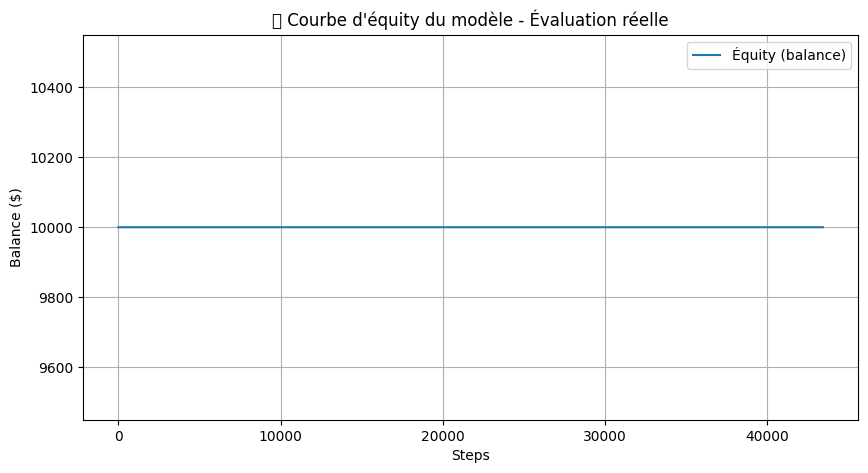

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

# === Paramètres ===
MODEL_PATH = "models/metatrader_ppo_final.zip"
initial_balance = 10000

# === Environnement sans RandomStartWrapper ===
test_env = DummyVecEnv([lambda: Monitor(ForexEnv(df_mt5))])

# === Chargement du modèle ===
model = PPO.load(MODEL_PATH, env=test_env)

# === Exécution d’un seul épisode “réel” ===
obs = test_env.reset()
if isinstance(obs, tuple):
    obs = obs[0]
obs = np.asarray(obs)
if obs.ndim == 1:
    obs = obs.reshape(1, -1)

balances, actions, rewards = [], [], []
done = False
step_count = 0
max_steps = len(df_mt5)

while not done and step_count < max_steps:
    action, _ = model.predict(obs, deterministic=True)

    res = test_env.step(action)
    if len(res) == 5:
        next_obs, reward, terminated, truncated, info = res
        if isinstance(terminated, (list, np.ndarray)):
            t0 = bool(terminated[0])
        else:
            t0 = bool(terminated)
        if isinstance(truncated, (list, np.ndarray)):
            tr0 = bool(truncated[0])
        else:
            tr0 = bool(truncated)
        done = t0 or tr0
    elif len(res) == 4:
        next_obs, reward, done_val, info = res
        if isinstance(done_val, (list, np.ndarray)):
            done = bool(done_val[0])
        else:
            done = bool(done_val)
    else:
        raise ValueError(f"Résultat inattendu de env.step(): {len(res)} éléments")

    # normaliser next_obs en (1, obs_dim)
    next_obs = np.asarray(next_obs)
    if next_obs.ndim == 1:
        obs = next_obs.reshape(1, -1)
    else:
        obs = next_obs

    # reward et action scalaires
    r = float(reward[0]) if isinstance(reward, (list, np.ndarray)) else float(reward)
    a = int(np.asarray(action).flatten()[0])

    balances.append(test_env.envs[0].unwrapped.balance)
    actions.append(a)
    rewards.append(r)

    step_count += 1

# === Statistiques finales ===
if len(balances) == 0:
    print("⚠️ Aucun pas enregistré — vérifiez que le modèle et l'environnement sont compatibles.")
else:
    final_balance = balances[-1]
    profit_pct = ((final_balance - initial_balance) / initial_balance) * 100

    print("\n📊 Évaluation finale du modèle (réel):")
    print(f"Balance initiale: {initial_balance:.2f}")
    print(f"Balance finale: {final_balance:.2f}")
    print(f"Profit/Perte: {profit_pct:.2f}%")
    print(f"Reward moyenne: {np.mean(rewards):.6f} ± {np.std(rewards):.6f}")

    # Distribution des actions
    unique, counts = np.unique(actions, return_counts=True)
    print("\n🎯 Action distribution:")
    for u, c in zip(unique, counts):
        print(f"  - Action {u}: {c} fois ({(c / len(actions)) * 100:.1f}%)")

    # Courbe d'équity
    plt.figure(figsize=(10, 5))
    plt.plot(balances, label="Équity (balance)")
    plt.title("📈 Courbe d'équity du modèle - Évaluation réelle")
    plt.xlabel("Steps")
    plt.ylabel("Balance ($)")
    plt.legend()
    plt.grid(True)
    plt.show()